In [21]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_excel('Result_28.xlsx')

Valores nulos restantes por coluna:
tipo_ticket                0
problema_nosso         21673
servico                19997
meio                       0
status_cliente             0
categoria               2440
hist                   19214
codcli                     0
consultor                  4
classificacao              0
data_criacao_ticket        0
id_ticket                  0
titulo                    11
colaborador            26703
data_atualizacao           0
duracao                47016
mensagem                2919
dtype: int64


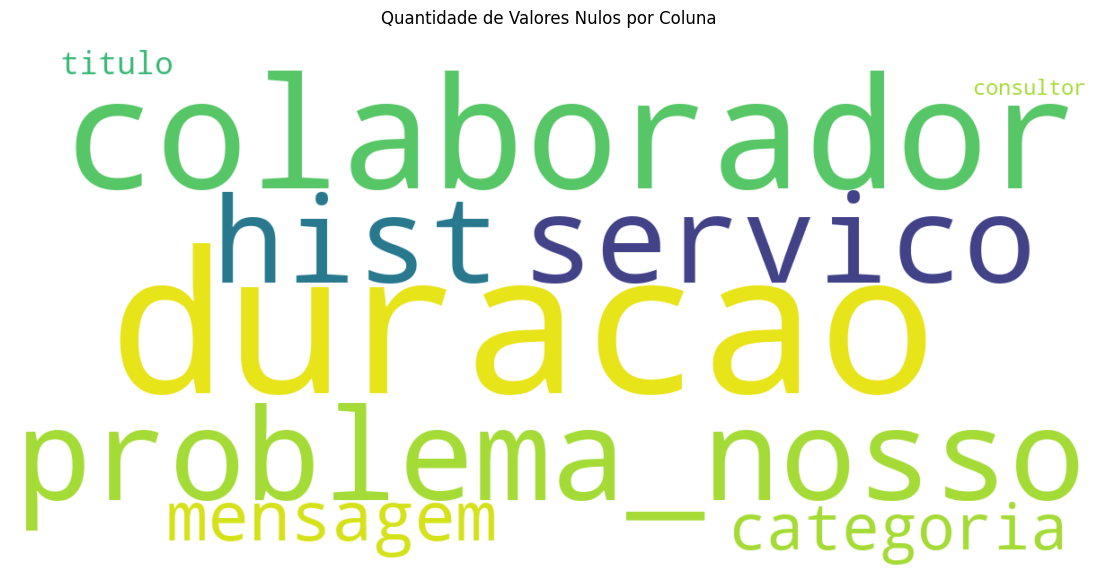

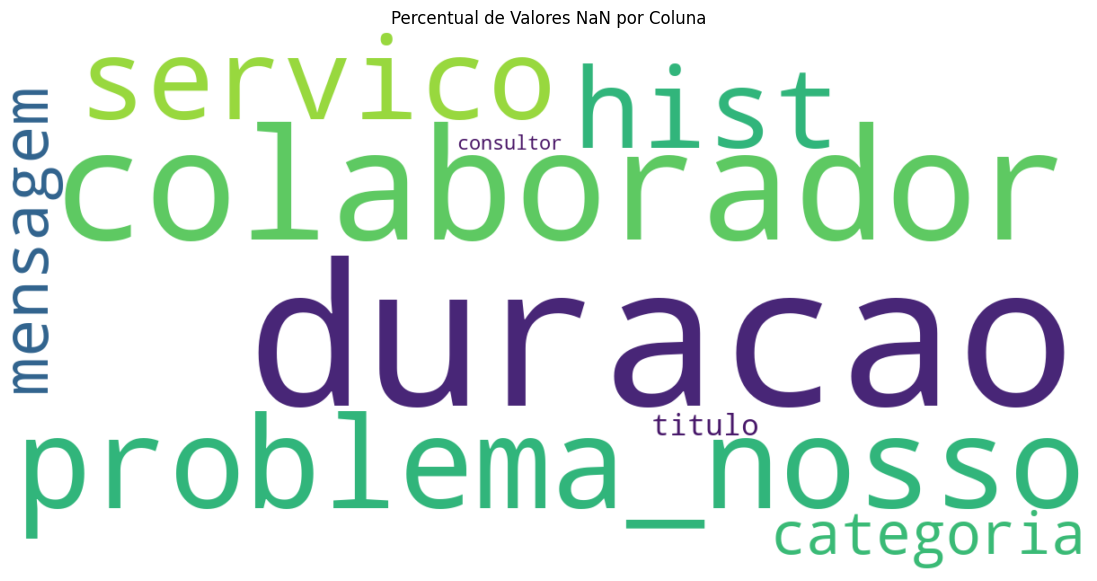

In [22]:


print("Valores nulos restantes por coluna:")
print(df.isnull().sum())



# =========================
# 1. Quantidade de NaN
# =========================
nan_counts = df.isnull().sum()

# Remove colunas sem NaN
nan_counts = nan_counts[nan_counts > 0]

# Cria dicionário no formato esperado pela WordCloud
frequencias_nan = nan_counts.to_dict()

# Gerar word cloud
wordcloud_nan = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate_from_frequencies(frequencias_nan)

# Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_nan, interpolation='bilinear')
plt.axis('off')
plt.title('Quantidade de Valores Nulos por Coluna')
plt.show()


# =========================
# 2. Percentual de NaN
# =========================
nan_percent = (df.isnull().mean() * 100)

# Remove colunas sem NaN
nan_percent = nan_percent[nan_percent > 0]

# Converter para dicionário
frequencias_percent = nan_percent.to_dict()

# Gerar word cloud
wordcloud_percent = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate_from_frequencies(frequencias_percent)

# Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_percent, interpolation='bilinear')
plt.axis('off')
plt.title('Percentual de Valores NaN por Coluna')
plt.show()

In [23]:
# 1. Tratamento do tempo e criação da coluna de minutos
df["duracao"] = df["duracao"].fillna("00:00:00")
df["duracao"] = pd.to_timedelta(df["duracao"], errors="coerce")
df["data_atualizacao"] = pd.to_datetime(df["data_atualizacao"], errors="coerce")

# Converter durações para formato HH:MM:SS (string) removendo 'days'
df['duracao_minutos_individual'] = df['duracao'].astype(str).str.replace(r'^(\d+ days?\s+)?', '', regex=True).str.split('.').str[0]

# 2. Somar a duração por ticket e criar coluna separada
df['duracao_minutos_total_por_ticket'] = df.groupby('id_ticket')['duracao'].transform('sum').astype(str).str.split('.').str[0]


# 3. Lista de colunas que NÃO queremos que o preenchimento automático toque
# (duracao já está preenchida, mensagem não será alterada, id_ticket é a chave)
colunas_ignoradas = ['id_ticket', 'duracao', 'duracao_minutos_individual', 'mensagem', 'duracao_minutos_total_por_ticket']

# Criar a lista de colunas para preencher (todas as outras colunas)
colunas_para_preencher = [col for col in df.columns if col not in colunas_ignoradas]

# 4. Preencher as lacunas em bloco (bfill e ffill) para cada ticket
df[colunas_para_preencher] = df.groupby('id_ticket')[colunas_para_preencher].transform(
    lambda x: x.bfill().ffill()
)
# 5. Remover a coluna de duração original, pois agora temos as colunas de minutos
df = df.drop('duracao', axis=1)

# 6. Remover os status pendentes, pois não são mais relevantes para a análise
df = df[df["status_cliente"].isin(["FECHADO"])]
df = df.dropna(subset=["status_cliente"])

# 7. Preencher valores nulos na coluna "problema_nosso"
df["problema_nosso"] = df["problema_nosso"].fillna("Indefinido", inplace= True)

# 8. Preencher valores nulos na coluna "servico"
df['servico'] = df['servico'].fillna("Serviço Indefinido", inplace= True)

# 9. Preencher valores nulos na coluna "categoria"
df['categoria'] = df['categoria'].fillna("Categoria Indefinida", inplace= True)

# 10. Preencher valores nulos na coluna "hist"
df['hist'] = df['hist'].fillna("Versão Indefinido", inplace= True)

# 11. Preencher valores nulos na coluna "consultor"
df['consultor'] = df['consultor'].fillna("Indefinido", inplace= True)

# 12. Preencher valores nulos na coluna "titulo"
df['titulo'] = df['titulo'].fillna("Sem título", inplace= True)

# 13. Preencher valores nulos na coluna "colaborador"
df['colaborador'] = df['colaborador'].fillna("Colaborador Indefinido", inplace= True)

# 14. Preencher valores nulos na coluna "data_atualizacao"
df['data_atualizacao'] = df['data_atualizacao'].fillna("00:00:00")

# 15. Preencher valores nulos na coluna "mensagem" e limpar caracteres de quebra de linha
df['mensagem'] = df['mensagem'].fillna("Sem mensagem", inplace= True)
# Remove "mailto:"
df["mensagem"] = df["mensagem"].str.replace("mailto:", "", regex=False)
# Remove emails
df["mensagem"] = df["mensagem"].str.replace(
    r'\S+@\S+',
    '',
    regex=True
)
# Remove entidades HTML &nbsp;
df["mensagem"] = df["mensagem"].str.replace("&nbsp;", " ", regex=False)
# Remove espaços extras novamente
df["mensagem"] = df["mensagem"].str.replace(r'\s+', ' ', regex=True).str.strip()

# 16. Ordenar categoria por ordem alfabética
ordem = ["A", "B", "C"]

df["classificacao"] = pd.Categorical(
    df["classificacao"],
    categories=ordem,
    ordered=True
)

df = df.sort_values("classificacao")




print("Valores nulos restantes por coluna:")
print(df.isnull().sum())



C:\Users\47822733800\AppData\Local\Temp\ipykernel_22116\2769397121.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["problema_nosso"] = df["problema_nosso"].fillna("Indefinido", inplace= True)
C:\Users\47822733800\AppData\Local\Temp\ipykernel_22116\2769397121.py:35: ChainedAssignmentError: A value is being set on a copy of a D

Valores nulos restantes por coluna:
tipo_ticket                         0
problema_nosso                      0
servico                             0
meio                                0
status_cliente                      0
categoria                           0
hist                                0
codcli                              0
consultor                           0
classificacao                       0
data_criacao_ticket                 0
id_ticket                           0
titulo                              0
colaborador                         0
data_atualizacao                    0
mensagem                            0
duracao_minutos_individual          0
duracao_minutos_total_por_ticket    0
dtype: int64


In [24]:
df

,tipo_ticket,problema_nosso,servico,meio,status_cliente,categoria,hist,codcli,consultor,classificacao,data_criacao_ticket,id_ticket,titulo,colaborador,data_atualizacao,mensagem,duracao_minutos_individual,duracao_minutos_total_por_ticket
43108,suporte,Indefinido,Serviço Indefinido,Portal Cliente,FECHADO,Nova Solicitação,Versão Indefinido,5463,Julio Cesar,A,2025-06-09 04:55,358272,Liberar site,Cleverton,2025-06-09 04:55:00,Liberar site,00:00:00,0 days 00:03:12
90135,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 40F s/ lic - Palmas Embrasil,4968,Janaina,A,2025-11-07 11:55,371606,Embrasil - Palmas Voip 3cx,João Paulo,2025-11-07 01:55:00,"Prezados, boa tarde.Configuração realizada par...",00:07:09,0 days 00:07:09
39400,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 04:55:00,Incluir servidores na regra do anydesk,00:00:00,0 days 00:17:00
39401,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 04:55:00,"Prezados,Boa tarde.Preciso que seja incluído n...",00:00:00,0 days 00:17:00
39402,suporte,SIM,Fortinet,Portal Cliente,FECHADO,Nova Solicitação,Fortigate 80F,2286,Janaina,A,2025-05-28 04:55,357296,Incluir servidores na regra do anydesk,Lucas,2025-05-28 05:55:00,"Navito, boa tarde!Conforme as regras criadas a...",00:04:42,0 days 00:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56537,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 03:55:00,Sem mensagem,00:00:37,0 days 00:07:14
56536,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 08:55:00,Estamos com um rompimento no trecho acima cons...,00:01:12,0 days 00:07:14
56535,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Problema,Rompimento,6075,CTI-ADM,C,2025-07-28 08:55,362043,Rompimento - MKT LOG - 28/07/2025,Allan,2025-07-28 08:55:00,Rompimento - MKT LOG - 28/07/2025,00:00:00,0 days 00:07:14
56531,suporte,SIM,Acesso Dedicado,WhatsApp,FECHADO,Nova Solicitação,Rompimento,4873,CTI-ADM,C,2025-07-26 01:55,362033,Rompimento - 5557-SMARTS_AVENIDA_POMPEIA-LD e ...,Ermerson,2025-07-26 07:55:00,"https://maps.google.com/?q=-23.5274437,-46.683...",00:03:24,0 days 00:40:30
